In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import mlflow
import src.config as config
from src.mlflow_init import init_mlflow

init_mlflow(config.EXPERIMENT_NAME)

EPOCHS = config.EPOCHS
BATCH_SIZE = config.BATCH_SIZE
RANDOM_SEED = config.RANDOM_SEED
IMAGE_SIZE = config.IMAGE_SIZE


<Experiment: artifact_location='file:///d:/Dev/tankri_ocr_proj/notebooks/mlruns/1', creation_time=1781137986058, experiment_id='1', last_update_time=1781137986058, lifecycle_stage='active', name='Tankri CNN', tags={}, trace_location=None, workspace='default'>

In [2]:
LABELS_PATH = "../dataset/labels/labels.csv"

df = pd.read_csv(LABELS_PATH)

df.head()

,image,label
0,1.png,𑚀
1,2.png,𑚁
2,3.png,𑚂
3,4.png,𑚃
4,5.png,𑚄


In [3]:
print(df.shape)
print(df.head())

(229, 2)
   image label
0  1.png     𑚀
1  2.png     𑚁
2  3.png     𑚂
3  4.png     𑚃
4  5.png     𑚄


In [4]:
from src.label_mapping import create_label_mapping, save_label_mapping

label_to_idx, idx_to_label = create_label_mapping(r"../dataset/labels/labels.csv")
save_label_mapping(label_to_idx, idx_to_label, "../artifacts")

NUM_CLASSES = len(label_to_idx)
print(NUM_CLASSES)

45


In [5]:
label_to_idx

{'𑚀': 0,
 '𑚀𑚫': 1,
 '𑚀𑚬': 2,
 '𑚁': 3,
 '𑚂': 4,
 '𑚃': 5,
 '𑚄': 6,
 '𑚅': 7,
 '𑚆': 8,
 '𑚇': 9,
 '𑚈': 10,
 '𑚉': 11,
 '𑚊': 12,
 '𑚋': 13,
 '𑚌': 14,
 '𑚍': 15,
 '𑚎': 16,
 '𑚏': 17,
 '𑚐': 18,
 '𑚑': 19,
 '𑚒': 20,
 '𑚓': 21,
 '𑚔': 22,
 '𑚕': 23,
 '𑚖': 24,
 '𑚗': 25,
 '𑚘': 26,
 '𑚙': 27,
 '𑚚': 28,
 '𑚛': 29,
 '𑚜': 30,
 '𑚝': 31,
 '𑚞': 32,
 '𑚟': 33,
 '𑚠': 34,
 '𑚡': 35,
 '𑚢': 36,
 '𑚣': 37,
 '𑚤': 38,
 '𑚥': 39,
 '𑚦': 40,
 '𑚧': 41,
 '𑚨': 42,
 '𑚩': 43,
 '𑚪': 44}

In [6]:
# Mappings are saved centrally in artifacts/ directory. No local generation needed.

In [7]:
IMAGE_SIZE = 256

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [8]:
class TankriDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):

        self.dataframe = dataframe

        self.image_dir = image_dir

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        image_name = self.dataframe.iloc[idx]["image"]

        label = self.dataframe.iloc[idx]["label"]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = Image.open(image_path)

        if self.transform:
            image = self.transform(image)

        label = label_to_idx[label]

        return image, label

c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 71296 (\N{TAKRI LETTER A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


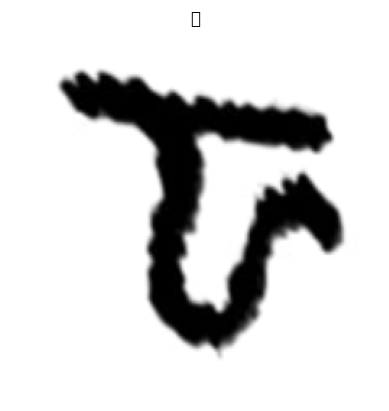

In [9]:
dataset = TankriDataset(
    dataframe=df,
    image_dir="../dataset/images",
    transform=transform
)
image, label = dataset[0]

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(idx_to_label[label])

plt.axis("off")

plt.show()

In [10]:
image, label = dataset[0]

print(type(image))
print(image.dtype)
print(image.shape)
print(label)
print(idx_to_label[label]) 
print(image.min())
print(image.max())

<class 'torch.Tensor'>
torch.float32
torch.Size([1, 256, 256])
0
𑚀
tensor(0.)
tensor(1.)


In [11]:
print(image[:, :5, :5])

tensor([[[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]]])


In [12]:
batch_size = config.BATCH_SIZE

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)


In [13]:
counts = df["label"].value_counts()

print(counts.sort_values())
print(counts[counts == 1])
print(counts[counts == 2])

label
𑚀𑚬    1
𑚪     1
𑚒     2
𑚓     2
𑚎     2
𑚂     3
𑚅     3
𑚣     3
𑚕     3
𑚌     4
𑚙     4
𑚡     4
𑚗     4
𑚨     5
𑚄     5
𑚔     5
𑚆     5
𑚍     5
𑚏     5
𑚇     5
𑚋     5
𑚜     5
𑚞     5
𑚠     5
𑚚     5
𑚐     5
𑚟     5
𑚩     6
𑚝     6
𑚛     6
𑚤     6
𑚖     6
𑚥     6
𑚑     6
𑚧     6
𑚘     6
𑚢     7
𑚊     7
𑚦     7
𑚉     8
𑚀𑚫    8
𑚃     8
𑚁     8
𑚈     8
𑚀     8
Name: count, dtype: int64
label
𑚪     1
𑚀𑚬    1
Name: count, dtype: int64
label
𑚓    2
𑚒    2
𑚎    2
Name: count, dtype: int64


In [14]:
counts = df["label"].value_counts()

# Keep only classes with at least 2 samples
valid_classes = counts[counts >= 2].index

df_filtered = df[df["label"].isin(valid_classes)].copy()

print("Original images :", len(df))
print("Filtered images :", len(df_filtered))

print("Original classes :", df["label"].nunique())
print("Filtered classes :", df_filtered["label"].nunique())

Original images : 229
Filtered images : 227
Original classes : 45
Filtered classes : 43


In [15]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42,
    stratify=df_filtered["label"],
)

print(len(train_df))
print(len(val_df))

181
46


In [16]:
print(train_df["label"].value_counts().sort_index())
print(val_df["label"].value_counts().sort_index())

label
𑚀     6
𑚀𑚫    6
𑚁     6
𑚂     2
𑚃     6
𑚄     4
𑚅     2
𑚆     4
𑚇     4
𑚈     6
𑚉     6
𑚊     6
𑚋     4
𑚌     3
𑚍     4
𑚎     2
𑚏     4
𑚐     4
𑚑     5
𑚒     2
𑚓     2
𑚔     4
𑚕     2
𑚖     5
𑚗     3
𑚘     5
𑚙     3
𑚚     4
𑚛     5
𑚜     4
𑚝     5
𑚞     4
𑚟     4
𑚠     4
𑚡     3
𑚢     6
𑚣     2
𑚤     5
𑚥     5
𑚦     6
𑚧     5
𑚨     4
𑚩     5
Name: count, dtype: int64
label
𑚀     2
𑚀𑚫    2
𑚁     2
𑚂     1
𑚃     2
𑚄     1
𑚅     1
𑚆     1
𑚇     1
𑚈     2
𑚉     2
𑚊     1
𑚋     1
𑚌     1
𑚍     1
𑚏     1
𑚐     1
𑚑     1
𑚔     1
𑚕     1
𑚖     1
𑚗     1
𑚘     1
𑚙     1
𑚚     1
𑚛     1
𑚜     1
𑚝     1
𑚞     1
𑚟     1
𑚠     1
𑚡     1
𑚢     1
𑚣     1
𑚤     1
𑚥     1
𑚦     1
𑚧     1
𑚨     1
𑚩     1
Name: count, dtype: int64


In [17]:
from src.label_mapping import load_label_mapping

label_to_idx, idx_to_label = load_label_mapping("../artifacts")
NUM_CLASSES = len(label_to_idx)

print(NUM_CLASSES)

43


In [18]:
# Mappings are saved centrally in artifacts/ directory. No local generation needed.

In [19]:
class TankriCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),


            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),


            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )

        )

        self.classifier = nn.Sequential(
            
            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),

            nn.Linear(
                128,
                num_classes
            )

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [20]:
# Instantiate model dynamically using config fields
if config.MODEL_NAME == "ResNet18":
    from src.models import ResNet18Model
    model = ResNet18Model(
        num_classes=NUM_CLASSES,
        pretrained=config.PRETRAINED,
        dropout=config.DROPOUT,
        unfreeze_layer3=config.UNFREEZE_LAYER3,
        unfreeze_layer4=config.UNFREEZE_LAYER4,
    )
elif config.MODEL_NAME == "SimpleCNN":
    from src.models import SimpleCNN
    model = SimpleCNN(
        num_classes=NUM_CLASSES,
        dropout=config.DROPOUT,
    )
else:
    raise ValueError(f"Unknown model name: {config.MODEL_NAME}")

print(model)


TankriCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=43, bias=True)
  )
)


In [21]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 98,219


In [22]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

model = model.to(device)

cuda


In [23]:
criterion = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTHING)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config.LEARNING_RATE
)


In [24]:
train_dataset = TankriDataset(
    dataframe=train_df,
    image_dir="../dataset/images",
    transform=transform
)

val_dataset = TankriDataset(
    dataframe=val_df,
    image_dir="../dataset/images",
    transform=transform
)

In [25]:
BATCH_SIZE = config.BATCH_SIZE

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [26]:
EPOCHS = config.EPOCHS

# Start an MLflow run
with mlflow.start_run(run_name=config.EXPERIMENT_NAME):

    # Configuration Logging (Snapshot and Parameters)
    from src.train import log_experiment_config, save_config_snapshot
    save_config_snapshot("config_snapshot.json")
    mlflow.log_artifact("config_snapshot.json")
    
    # Dynamically log all experiment config values
    log_experiment_config()

    # Automatically serialize the torchvision augmentation config and log it
    transform = getattr(train_loader.dataset, "transform", None)
    if transform is not None:
        from src.experiment_logging import save_augmentation_config
        aug_path = save_augmentation_config(transform, "augmentation_config.txt")
        mlflow.log_artifact(str(aug_path))

    train_losses = []
    train_accuracies = []

    val_losses = []
    val_accuracies = []

    best_val_acc = 0.0
    best_epoch = 0

    for epoch in range(EPOCHS):

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Apply MixUp if configured
        from src.config import MIXUP_ALPHA
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            
            if MIXUP_ALPHA > 0.0:
                import numpy as np
                lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
                batch_size_curr = images.size()[0]
                index = torch.randperm(batch_size_curr).to(device)
                mixed_images = lam * images + (1 - lam) * images[index]
                labels_a, labels_b = labels, labels[index]
                
                outputs = model(mixed_images)
                loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item()
                predictions = outputs.argmax(dim=1)
                correct += (lam * (predictions == labels_a).sum().item() + (1 - lam) * (predictions == labels_b).sum().item())
                total += labels.size(0)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item()
                predictions = outputs.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                predictions = outputs.argmax(dim=1)
                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)
        val_loss = val_running_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_accuracy", train_acc, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("val_accuracy", val_acc, step=epoch)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), "best_model.pth")

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    mlflow.log_metric("best_val_accuracy", best_val_acc)
    mlflow.log_metric("best_epoch", best_epoch)
    mlflow.set_tag("best_epoch", str(best_epoch))
    mlflow.set_tag("best_val_accuracy", str(best_val_acc))

    # Log evaluation artifacts via the evaluation module
    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies,
    }
    from src.evaluate import log_evaluation_artifacts
    log_evaluation_artifacts(
        model=model,
        val_loader=val_loader,
        device=device,
        save_dir=".",
        history=history,
        label_to_idx=label_to_idx,
        idx_to_label=idx_to_label,
    )


Epoch [1/20] | Train Loss: 3.7711 | Train Acc: 0.0110 | Val Loss: 3.7413 | Val Acc: 0.0435
Epoch [2/20] | Train Loss: 3.7540 | Train Acc: 0.0110 | Val Loss: 3.7269 | Val Acc: 0.0217
Epoch [3/20] | Train Loss: 3.7425 | Train Acc: 0.0276 | Val Loss: 3.7158 | Val Acc: 0.0217
Epoch [4/20] | Train Loss: 3.7278 | Train Acc: 0.0221 | Val Loss: 3.7163 | Val Acc: 0.0217
Epoch [5/20] | Train Loss: 3.7287 | Train Acc: 0.0276 | Val Loss: 3.7100 | Val Acc: 0.0435
Epoch [6/20] | Train Loss: 3.7251 | Train Acc: 0.0442 | Val Loss: 3.7085 | Val Acc: 0.0217
Epoch [7/20] | Train Loss: 3.7209 | Train Acc: 0.0276 | Val Loss: 3.7067 | Val Acc: 0.0435
Epoch [8/20] | Train Loss: 3.7127 | Train Acc: 0.0497 | Val Loss: 3.7062 | Val Acc: 0.0652
Epoch [9/20] | Train Loss: 3.7170 | Train Acc: 0.0387 | Val Loss: 3.7052 | Val Acc: 0.0652
Epoch [10/20] | Train Loss: 3.7117 | Train Acc: 0.0387 | Val Loss: 3.7013 | Val Acc: 0.0652
Epoch [11/20] | Train Loss: 3.7131 | Train Acc: 0.0552 | Val Loss: 3.6984 | Val Acc: 0.06

2026/06/11 19:10:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 19:10:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch [20/20] | Train Loss: 3.6775 | Train Acc: 0.0442 | Val Loss: 3.6768 | Val Acc: 0.0217


2026/06/11 19:10:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/11 19:10:27 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


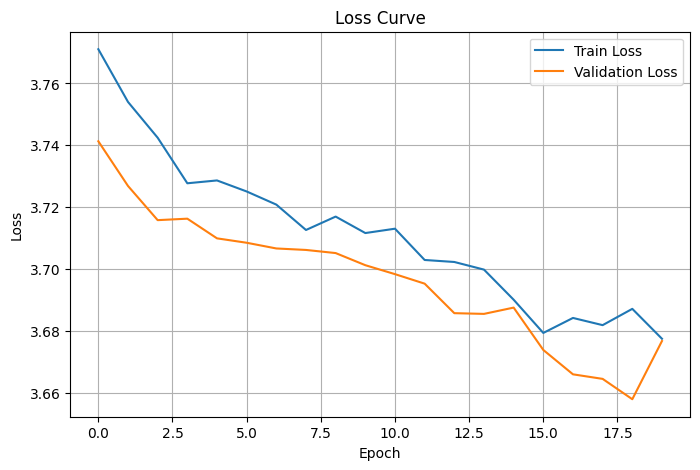

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.grid()

plt.show()

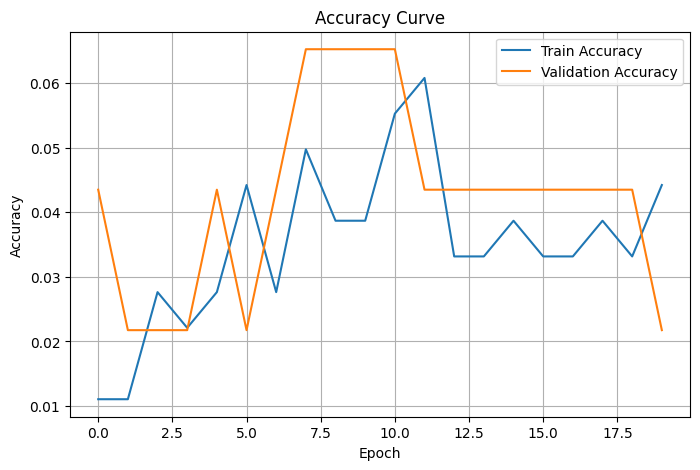

In [28]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.grid()

plt.show()

In [29]:
from sklearn.metrics import confusion_matrix
import numpy as np
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm.shape)

(40, 40)


In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            idx_to_label[i]
            for i in range(NUM_CLASSES)
        ],
        zero_division=0
    )
)

ValueError: Number of classes, 40, does not match size of target_names, 43. Try specifying the labels parameter